# Ensemble

本ノートブックでは、`04_modeling.ipynb` で選定した単体モデルを組み合わせ、アンサンブルによる改善余地を検証する。  

目的は、単体スコアの最良モデルをそのまま採用することではなく、**異なる予測傾向を持つモデルを組み合わせることで、誤差を補完できるかを確認すること**である。  

In [1]:
import sys
import warnings

sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from catboost import CatBoostRegressor
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler

from src.preprocessing import impute_missing, convert_object_to_category
from src.features import add_features, add_neighborhood_features, add_target_encoding_features, FEATURES
from src.utils import run_oof, rmse, seed_everything

SEED = 123
seed_everything(SEED)

## 1. 単体モデル予測の準備

まず、`04_modeling.ipynb` で採用候補とした単体モデルの予測を再作成する。  

各モデルの学習データは `04_modeling.ipynb` と同じ前処理・特徴量生成の流れを踏襲し、**アンサンブルの比較対象となる予測値を揃えること**を重視した。  

なお、Ridge は `04_modeling.ipynb` の CV 比較で線形モデル内の最下位だったため、アンサンブル候補から除外した。

In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df  = pd.read_csv("../data/test.csv")

y = train_df["SalePrice"]
train_df = train_df.drop("SalePrice", axis=1)

df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

In [3]:
# 前処理
df = impute_missing(df)
df = convert_object_to_category(df)

In [4]:
# 特徴量生成
df = add_features(df)

train = df.iloc[:len(y)].copy()
test  = df.iloc[len(y):].copy()

train = add_neighborhood_features(train, train)
test  = add_neighborhood_features(test, train)

# KFold Target Encoding
train["SalePrice"] = y.values
train, test = add_target_encoding_features(train, test, target_col="SalePrice")
train = train.drop("SalePrice", axis=1)

X_train = train[FEATURES]
y_train = np.log1p(y)
X_test  = test[FEATURES]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (1460, 45)
X_test:  (1459, 45)


In [5]:
# XGBoost用: category型を数値に変換
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

for col in X_train_xgb.select_dtypes(include="category").columns:
    X_train_xgb[col] = X_train_xgb[col].cat.codes
    X_test_xgb[col] = X_test_xgb[col].cat.codes

# 線形モデル共通: category型をダミー変数に変換
X_train_linear = pd.get_dummies(X_train)
X_test_linear = pd.get_dummies(X_test)

X_train_linear, X_test_linear = X_train_linear.align(X_test_linear, join="left", axis=1, fill_value=0)

X_train_linear = X_train_linear.fillna(0)
X_test_linear = X_test_linear.fillna(0)

scaler = StandardScaler()
X_train_linear = pd.DataFrame(
    scaler.fit_transform(X_train_linear),
    columns=X_train_linear.columns
)
X_test_linear = pd.DataFrame(
    scaler.transform(X_test_linear),
    columns=X_test_linear.columns
)

In [ ]:
# LightGBM (Optunaベストパラメータ)
params_lgb = {
    "boosting_type"  : "gbdt",
    "objective"      : "regression",
    "metric"         : "rmse",
    "random_state"   : SEED,
    "importance_type": "gain",
    "n_estimators"   : 100000,
    "learning_rate"  : 0.0283,
    "num_leaves"     : 53,
    "max_depth"      : 3,
    "lambda_l1"      : 0.0286,
    "lambda_l2"      : 0.192,
}

lgb_model = lgb.LGBMRegressor(**params_lgb)
lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_test)
print("pred_lgb shape:", pred_lgb.shape)

In [7]:
# XGBoost (Optunaベストパラメータ)
params_xgb = {
    "objective"        : "reg:squarederror",
    "eval_metric"      : "rmse",
    "learning_rate"    : 0.011,
    "max_depth"        : 4,
    "n_estimators"     : 1000,
    "random_state"     : SEED,
    "subsample"        : 0.51,
    "colsample_bytree" : 0.55,
    "reg_alpha"        : 0.48,
    "reg_lambda"       : 0.82,
}

xgb_model = xgb.XGBRegressor(**params_xgb)
xgb_model.fit(X_train_xgb, y_train)
pred_xgb = xgb_model.predict(X_test_xgb)
print("pred_xgb shape:", pred_xgb.shape)

pred_xgb shape: (1459,)


In [8]:
# CatBoost (Optunaベストパラメータ)
params_cat = {
    "loss_function" : "RMSE",
    "learning_rate" : 0.022,
    "depth"         : 7,
    "iterations"    : 10000,
    "random_seed"   : SEED,
    "l2_leaf_reg"   : 0.29,
    "verbose"       : 0,
}

cat_features = [col for col in X_train.columns if X_train[col].dtype.name == "category"]
cat_model = CatBoostRegressor(**params_cat)
cat_model.fit(X_train, y_train, cat_features=cat_features)
pred_cat = cat_model.predict(X_test)
print("pred_cat shape:", pred_cat.shape)

pred_cat shape: (1459,)


In [9]:
# Lasso (alpha=0.001)
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train_linear, y_train)
pred_lasso = lasso_model.predict(X_test_linear)
print("pred_lasso shape:", pred_lasso.shape)

pred_lasso shape: (1459,)


In [10]:
# ElasticNet (alpha=0.001, l1_ratio=0.8)
elastic_model = ElasticNet(alpha=0.001, l1_ratio=0.8)
elastic_model.fit(X_train_linear, y_train)
pred_elastic = elastic_model.predict(X_test_linear)
print("pred_elastic shape:", pred_elastic.shape)

pred_elastic shape: (1459,)


## 2. モデル予測の相関確認

アンサンブルでは、単体性能だけでなく、各モデルの予測がどの程度似ているかも重要になる。  
予測が近いモデル同士を平均しても改善幅は限られるため、ここでは単体モデルの test 予測同士の相関を確認する。

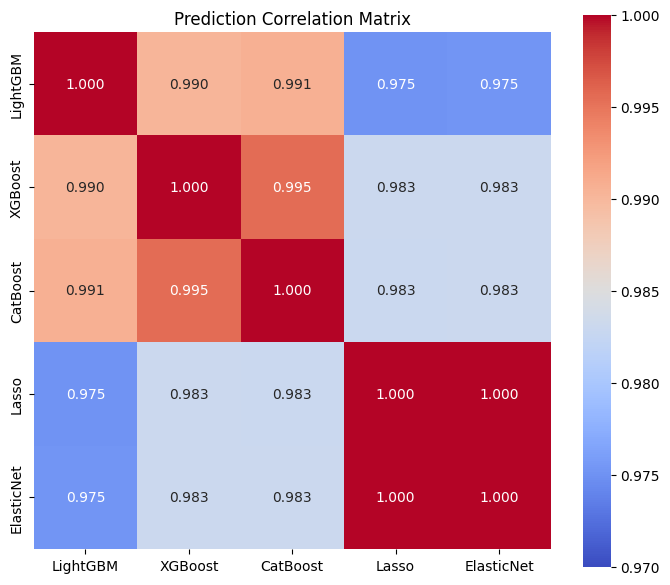

In [16]:
# モデル予測同士の相関ヒートマップ
pred_df = pd.DataFrame({
    "LightGBM": pred_lgb,
    "XGBoost": pred_xgb,
    "CatBoost": pred_cat,
    "Lasso": pred_lasso,
    "ElasticNet": pred_elastic,
})

corr = pred_df.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', square=True,
            vmin=0.97, vmax=1.0, cmap='coolwarm')
plt.title("Prediction Correlation Matrix")
plt.tight_layout()
plt.show()

木系3モデル同士の相関は 0.990〜0.995 と非常に高く、互いに近い予測を返していた。  
Lasso と ElasticNet も 1.000 とほぼ同一であり、線形モデル同士の差はほとんど見られなかった。  

一方で、木系モデルと線形モデルの相関は 0.975〜0.983 とわずかに低く、線形モデルは木系モデルを補完する候補として加える余地があると判断した。

## 3. 単体モデルの整理

ここまでの予測相関を踏まえ、各モデルの単体 LB スコアと系統を確認し、アンサンブルに残す候補を整理する。

In [17]:
# アンサンブル候補として採用した単体モデルのLBスコア一覧
lb_scores = {
    "LightGBM": 0.12993,
    "XGBoost": 0.12825,
    "CatBoost": 0.12709,
    "Lasso": 0.12560,
    "ElasticNet": 0.12555,
}

single_model_results = pd.DataFrame({
    "Model": list(lb_scores.keys()),
    "LB_Score": list(lb_scores.values()),
})

single_model_results["Type"] = ["Tree", "Tree", "Tree", "Linear", "Linear"]
single_model_results["Role"] = ["基準モデル", "木系候補", "木系候補", "線形候補", "線形候補"]

single_model_results = single_model_results.sort_values("LB_Score").reset_index(drop=True)
single_model_results.index = single_model_results.index + 1
single_model_results

,Model,LB_Score,Type,Role
1,ElasticNet,0.12555,Linear,線形候補
2,Lasso,0.12560,Linear,線形候補
3,CatBoost,0.12709,Tree,木系候補
4,XGBoost,0.12825,Tree,木系候補
5,LightGBM,0.12993,Tree,基準モデル



単体 LB スコアでは ElasticNet と Lasso が上位となった一方、木系モデルも一定のスコアを維持していた。  
セクション2の相関確認では、木系と線形で予測傾向に差があることを確認しており、単体スコアだけで候補を絞るのではなく、両系統をアンサンブルに残す方針とした。  

## 4. 単純平均

まず、最もシンプルなアンサンブル手法として、全モデルの予測値の単純平均を試す。  
各モデルに等しい重みを与えるため、特定のモデルに依存しにくく、実装・解釈ともに素直である。  

次のセクションで加重平均と比較し、重み付けの導入による改善幅を確認する。

In [ ]:
# 単純平均
pred_simple = (
    pred_lgb +
    pred_xgb +
    pred_cat +
    pred_lasso +
    pred_elastic
) / 5

print("pred_simple shape:", pred_simple.shape)

## アンサンブル CV（OOF）

oof_lgb     = run_oof(lgb.LGBMRegressor(**params_lgb), X_train, y_train, random_state=SEED)
oof_xgb     = run_oof(xgb.XGBRegressor(**params_xgb), X_train_xgb, y_train, random_state=SEED)
oof_cat     = run_oof(CatBoostRegressor(**params_cat), X_train, y_train, random_state=SEED)
oof_lasso   = run_oof(Lasso(alpha=0.001), X_train_linear, y_train, random_state=SEED)
oof_elastic = run_oof(ElasticNet(alpha=0.001, l1_ratio=0.8), X_train_linear, y_train, random_state=SEED)

# 単体CV
print("--- 単体モデル CV (RMSE) ---")
for name, oof in [("LightGBM", oof_lgb), ("XGBoost", oof_xgb),
                   ("CatBoost", oof_cat), ("Lasso", oof_lasso),
                   ("ElasticNet", oof_elastic)]:
    print(f"  {name}: {rmse(y_train, oof):.5f}")

# アンサンブルCV（単純平均）
oof_simple = np.mean([oof_lgb, oof_xgb, oof_cat, oof_lasso, oof_elastic], axis=0)
print(f"\n--- アンサンブル CV (単純平均 RMSE) ---")
print(f"  {rmse(y_train, oof_simple):.5f}")

In [19]:
test_ids = test["Id"]
pred_final = np.expm1(pred_simple)

submission = pd.DataFrame({"Id": test_ids, "SalePrice": pred_final})
submission.to_csv("../submissions/submission_ensemble_simple.csv", index=False)
print("Saved!")

Saved!


## 5. 加重平均

単純平均では全モデルに等しい重みを与えるが、単体性能に差がある場合、**性能の良いモデルにより大きな重みを与えることで改善できるか**を検証する。

重みの算出には inverse-score weighting（LBスコアの逆数を正規化）を用いた。  
LBスコアが低い（＝性能が良い）モデルほど大きな重みを受け取る仕組みである。  

ただし、今回の単体LBスコアは 0.125〜0.130 の狭い範囲に収まっているため、算出される重みは各モデルほぼ 0.20 前後となり、単純平均との差は小さくなることが予想される。

In [20]:
# 単体LBスコアをもとに、簡易な重み付け平均を作成
weight_keys = {
    "lgb": "LightGBM",
    "xgb": "XGBoost",
    "cat": "CatBoost",
    "lasso": "Lasso",
    "elastic": "ElasticNet",
}

weights = {k: 1 / lb_scores[v] for k, v in weight_keys.items()}
total = sum(weights.values())
weights = {k: v / total for k, v in weights.items()}

print(weights)

# 加重平均
pred_weighted = (
    weights["lgb"]     * pred_lgb +
    weights["xgb"]     * pred_xgb +
    weights["cat"]     * pred_cat +
    weights["lasso"]   * pred_lasso +
    weights["elastic"] * pred_elastic
)

print("pred_weighted shape:", pred_weighted.shape)

# 単体CV　（単純平均と同じ基準で比較するため、ここでも各単体モデルのCVを確認する）
print("--- 単体モデル CV (RMSE) ---")
for name, oof in [("LightGBM", oof_lgb), ("XGBoost", oof_xgb),
                   ("CatBoost", oof_cat), ("Lasso", oof_lasso),
                   ("ElasticNet", oof_elastic)]:
    print(f"  {name}: {rmse(y_train, oof):.5f}")

# アンサンブルCV（加重平均）
oof_weighted = (
    weights["lgb"]     * oof_lgb +
    weights["xgb"]     * oof_xgb +
    weights["cat"]     * oof_cat +
    weights["lasso"]   * oof_lasso +
    weights["elastic"] * oof_elastic
)
print(f"--- アンサンブル CV (加重平均 RMSE) ---")
print(f"  {rmse(y_train, oof_weighted):.5f}")

{'lgb': 0.1958937993304626, 'xgb': 0.19845989354391427, 'cat': 0.20027131439929977, 'lasso': 0.20264714448253987, 'elastic': 0.20272784824378343}
pred_weighted shape: (1459,)
--- 単体モデル CV (RMSE) ---
  LightGBM: 0.12640
  XGBoost: 0.12369
  CatBoost: 0.11863
  Lasso: 0.12287
  ElasticNet: 0.12280
--- アンサンブル CV (加重平均 RMSE) ---
  0.11684


In [21]:
test_ids = test["Id"]
pred_final = np.expm1(pred_weighted)

submission = pd.DataFrame({"Id": test_ids, "SalePrice": pred_final})
submission.to_csv("../submissions/submission_ensemble_weighted.csv", index=False)
print("Saved!")

Saved!


## 6. アンサンブル比較

単純平均と加重平均の結果を比較し、どちらを最終提出とするかを判断する。

In [22]:
used_models = "LGB + XGB + CAT + Lasso + ElasticNet"

ensemble_results = pd.DataFrame({
    "Method": ["単純平均", "加重平均"],
    "Used Models": [used_models, used_models],
    "CV RMSE": [
        rmse(y_train, oof_simple),
        rmse(y_train, oof_weighted),
    ],
    "LB Score": [0.12022, 0.12021],
    "Output File": [
        "submission_ensemble_simple.csv",
        "submission_ensemble_weighted.csv",
    ]
})

ensemble_results.index = ensemble_results.index + 1
ensemble_results

,Method,Used Models,CV RMSE,LB Score,Output File
1,単純平均,LGB + XGB + CAT + Lasso + ElasticNet,0.116861,0.12022,submission_ensemble_simple.csv
2,加重平均,LGB + XGB + CAT + Lasso + ElasticNet,0.116838,0.12021,submission_ensemble_weighted.csv


LB スコアの差は 0.00001 であり、重み付けによる改善はほぼ見られなかった。  
これはセクション5で予想した通り、単体LBスコアが 0.125〜0.130 の狭い範囲に収まっているため、算出される重みがほぼ均等（各モデル約 0.20）になったことが原因と考えられる。 

最終提出には単純平均（LB 0.12022）を採用した。加重平均の重みは提出時の LB スコアに基づいており、未知のデータに対して同じ効果が得られるとは限らないため、より汎用的な単純平均を選択した。

## 7. Summary

本ノートブックでは、04_modeling.ipynb で選定した5モデルの予測を組み合わせ、アンサンブルによる改善余地を検証した。

単体最良の ElasticNet（LB 0.12555）に対し、5モデルの単純平均では **LB 0.12022** を達成した。
CV（OOF）でも単体最良の CatBoost（RMSE 0.11821）に対し、アンサンブルでは **RMSE 0.11686** となり、**LB・CV の両方で改善を確認できた。**
具体的には、木系と線形の予測相関が 0.975〜0.983 と完全には一致せず、この差がアンサンブルの改善幅につながった。

単純平均と加重平均の差は LB で 0.00001、CV で 0.00002 にとどまり、重み付けの効果は限定的だった。
加重平均の重みは提出時の LB スコアに基づいており汎用性に欠けるため、**最終提出には 単純平均（LB 0.12022） を採用**した。

全体を通じて得た学びは以下の 2 点である。

- **アンサンブルの改善幅は、モデルの多様性から生まれる。** → 単体スコアが高いモデルを並べるだけでなく、異なる仮定を持つモデル（木系と線形）を組み合わせることで、互いの弱点を補完できる。モデル選定では「強さ」だけでなく「違い」を意識する必要がある
- **手法の複雑さと効果は比例しない。** → 加重平均は単純平均より手法として高度だが、今回は差がほぼなかった。手法を複雑にする前に、その複雑さに見合う改善があるかを確認し、根拠が弱いなら単純な方を選ぶ判断が重要である